# CO3133 — Deep Learning and Its Applications
## Assignment 1: Foundations of Deep Learning Pipelines and Architectures
### Topic: From Linear Models to Modern Sequence Models: A Comparative Study for Image Classification

---
**Course:** CO3133 - Deep Learning and Its Applications  
**Assignment:** 1 - Core Implementation  
**Dataset:** Fashion-MNIST (Grayscale 28×28, 10 Classes)  
**Models Evaluated:**
1. Linear / Softmax Classifier
2. Multilayer Perceptron (MLP)
3. Convolutional Neural Network (CNN)
4. Long Short-Term Memory Network (LSTM)
5. Vision Transformer (ViT from Scratch)

---
### Controlled Experiment Workflow
```text
Fashion-MNIST (60,000 Train + 10,000 Test)
      ↓
Exploratory Data Analysis (EDA)
      ↓
Fixed Split: Train (54,000) / Validation (6,000) / Test (10,000) [Seed=42]
      ↓
Preprocessing (Z-score Normalization) + Augmentation (Train only)
      ↓
DataLoaders (Train: shuffle=True; Val/Test: shuffle=False)
      ↓
Unified Training & Checkpoint Engine (Lowest Val Loss)
      ↓
 ┌──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
 │ Linear Model │     MLP      │     CNN      │     LSTM     │ Transformer  │
 └──────────────┴──────────────┴──────────────┴──────────────┴──────────────┘
      ↓
Best Checkpoints Loaded
      ↓
Final Test Evaluation (Accuracy, Macro-F1, Parameters, Latency)
      ↓
Comprehensive Model Comparison & Error Analysis (Confusion Matrices & Failure Modes)
```

## 0. Configuration and Environment

In this section, we define a centralized configuration dictionary containing all seeds, data paths, model hyperparameters, and directory structures. We also detect the hardware acceleration backend (`CUDA`, `MPS`, or `CPU`) and set seeds across all libraries to ensure strict reproducibility.

In [1]:
import os
import sys
import time
import json
import random
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List, Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# ---------------------------------------------------------
# Optional: Google Drive Mounting (Colab Persistence)
# ---------------------------------------------------------
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Set MOUNT_DRIVE = True if you want to permanently store checkpoints in Google Drive
MOUNT_DRIVE = True

if IN_COLAB and MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    # Set your project workspace directory in Google Drive
    PROJECT_DIR = '/content/drive/MyDrive/BTL-deep_learning/assignment1'
    os.makedirs(PROJECT_DIR, exist_ok=True)
    os.chdir(PROJECT_DIR)
    print(f"[COLAB] Working directory set to: {os.getcwd()}")
else:
    PROJECT_DIR = "."
    print(f"[LOCAL/VM] Working directory set to: {os.path.abspath(PROJECT_DIR)}")

# ---------------------------------------------------------
# Centralized Configuration
# ---------------------------------------------------------
SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
NUM_CLASSES = 10
WEIGHT_DECAY = 1e-4

DATA_DIR = os.path.join(PROJECT_DIR, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
HISTORY_DIR = os.path.join(PROJECT_DIR, "histories")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURE_DIR = os.path.join(PROJECT_DIR, "figures")

# Master training control flags
# When RUN_ALL_FROM_SCRATCH is True, all models are retrained.
# When False, each model obeys its respective flag in TRAIN_FLAGS (loads checkpoint if False).
RUN_ALL_FROM_SCRATCH = False

TRAIN_FLAGS = {
    "linear": False,
    "mlp": False,
    "cnn": False,
    "lstm": False,
    "transformer": False
}

if RUN_ALL_FROM_SCRATCH:
    for k in TRAIN_FLAGS:
        TRAIN_FLAGS[k] = True

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Create directories
for d in [DATA_DIR, CHECKPOINT_DIR, HISTORY_DIR, RESULTS_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

# ---------------------------------------------------------
# Reproducibility Function
# ---------------------------------------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ---------------------------------------------------------
# Device Selection and Hardware Logging
# ---------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("=" * 60)
print("ENVIRONMENT & REPRODUCIBILITY SUMMARY")
print("=" * 60)
print(f"OS Platform         : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"Python Version      : {sys.version.split()[0]}")
print(f"PyTorch Version     : {torch.__version__}")
print(f"Torchvision Version : {torchvision.__version__}")
print(f"Selected Device     : {device}")
if device.type == "cuda":
    print(f"CUDA Device Name    : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Capability     : {torch.cuda.get_device_capability(0)}")
    print(f"CUDA Device Count   : {torch.cuda.device_count()}")
print(f"Global Random Seed  : {SEED}")
print(f"Master Batch Size   : {BATCH_SIZE}")
print(f"Master Epochs       : {NUM_EPOCHS}")
print(f"Master Learning Rate: {LEARNING_RATE}")
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[COLAB] Working directory set to: /content/drive/MyDrive/BTL-deep_learning/assignment1
ENVIRONMENT & REPRODUCIBILITY SUMMARY
OS Platform         : Linux 6.6.122+ (x86_64)
Python Version      : 3.13.15
PyTorch Version     : 2.11.0+cu128
Torchvision Version : 0.26.0+cu128
Selected Device     : cuda
CUDA Device Name    : Tesla T4
CUDA Capability     : (7, 5)
CUDA Device Count   : 1
Global Random Seed  : 42
Master Batch Size   : 64
Master Epochs       : 20
Master Learning Rate: 0.001


## 1. Fashion-MNIST Dataset Loading

We download and load the official **Fashion-MNIST** dataset using `torchvision.datasets.FashionMNIST`.
- **Raw Training Set:** 60,000 grayscale images (28×28 pixels).
- **Raw Test Set:** 10,000 grayscale images (28×28 pixels).
- **Classes:** 10 categories of fashion articles.

*Note:* In this step, we inspect raw PIL / tensor representations without applying transformations to understand the raw data structure.

In [2]:
# Load raw training and testing datasets without transformations for EDA
raw_train_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

raw_test_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print(f"Raw Train samples: {len(raw_train_dataset):,}")
print(f"Raw Test samples : {len(raw_test_dataset):,}")
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Class labels     : {CLASS_NAMES}")

Raw Train samples: 60,000
Raw Test samples : 10,000
Number of classes: 10
Class labels     : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. Exploratory Data Analysis (EDA)

A comprehensive exploratory analysis is conducted to inspect:
1. **Dataset Overview & Metadata**
2. **Pixel Properties & Value Ranges**
3. **Class Distribution & Frequency Table**
4. **Class Imbalance Quantification (Max/Min Ratio)**
5. **Representative Sample Grid for All 10 Classes**
6. **Class-Averaged Images & Global Pixel Intensity Distribution**

In [3]:
# ---------------------------------------------------------
# 2.1 & 2.2: Input Size, Dtype, and Pixel Statistics
# ---------------------------------------------------------
sample_img, sample_label = raw_train_dataset[0]
print("--- RAW SAMPLE INSPECTION ---")
print(f"Tensor Shape       : {sample_img.shape} (Channels, Height, Width)")
print(f"Tensor Data Type   : {sample_img.dtype}")
print(f"Min Pixel Value    : {sample_img.min().item():.4f}")
print(f"Max Pixel Value    : {sample_img.max().item():.4f}")
print(f"Sample Label ID    : {sample_label} ({CLASS_NAMES[sample_label]})")

# Calculate dataset-wide pixel mean and standard deviation on the 60,000 raw training images
train_loader_for_stats = DataLoader(raw_train_dataset, batch_size=5000, shuffle=False)
pixel_sum = 0.0
pixel_sq_sum = 0.0
total_pixels = 0

for imgs, _ in train_loader_for_stats:
    pixel_sum += imgs.sum().item()
    pixel_sq_sum += (imgs ** 2).sum().item()
    total_pixels += imgs.numel()

raw_mean = pixel_sum / total_pixels
raw_std = np.sqrt((pixel_sq_sum / total_pixels) - (raw_mean ** 2))

print(f"Calculated Raw Training Mean: {raw_mean:.4f}")
print(f"Calculated Raw Training Std : {raw_std:.4f}")

--- RAW SAMPLE INSPECTION ---
Tensor Shape       : torch.Size([1, 28, 28]) (Channels, Height, Width)
Tensor Data Type   : torch.float32
Min Pixel Value    : 0.0000
Max Pixel Value    : 1.0000
Sample Label ID    : 9 (Ankle boot)
Calculated Raw Training Mean: 0.2860
Calculated Raw Training Std : 0.3530


--- CLASS DISTRIBUTION TABLE ---
 Class ID  Class Name  Count  Percentage (%)
        0 T-shirt/top   6000            10.0
        1     Trouser   6000            10.0
        2    Pullover   6000            10.0
        3       Dress   6000            10.0
        4        Coat   6000            10.0
        5      Sandal   6000            10.0
        6       Shirt   6000            10.0
        7     Sneaker   6000            10.0
        8         Bag   6000            10.0
        9  Ankle boot   6000            10.0

--- IMBALANCE QUANTITATIVE ANALYSIS ---
Minimum Class Count : 6000
Maximum Class Count : 6000
Max / Min Ratio     : 1.0000
Observation         : The dataset is perfectly balanced with exactly 6000 samples per class (10.0% each).


/tmp/ipykernel_8430/2934445169.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  targets = np.array(raw_train_dataset.targets)


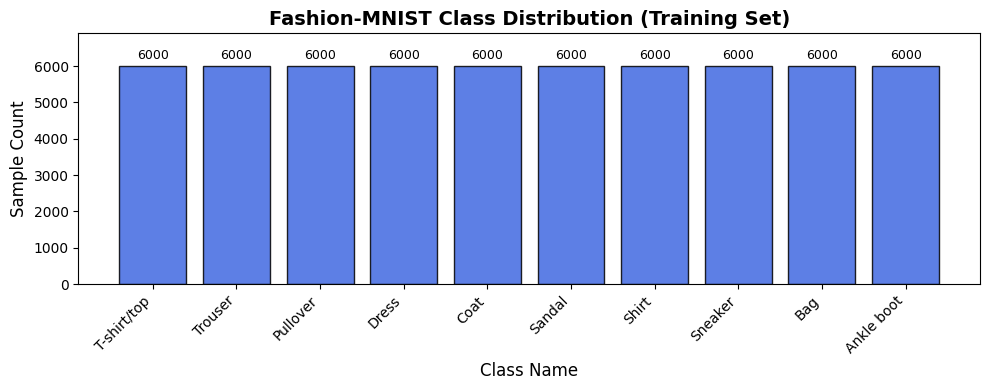

In [4]:
# ---------------------------------------------------------
# 2.3 & 2.4: Class Distribution and Imbalance Quantification
# ---------------------------------------------------------
targets = np.array(raw_train_dataset.targets)
class_counts = np.bincount(targets, minlength=NUM_CLASSES)
total_samples = len(targets)

df_distribution = pd.DataFrame({
    "Class ID": range(NUM_CLASSES),
    "Class Name": CLASS_NAMES,
    "Count": class_counts,
    "Percentage (%)": (class_counts / total_samples) * 100.0
})

print("--- CLASS DISTRIBUTION TABLE ---")
print(df_distribution.to_string(index=False))

min_count = class_counts.min()
max_count = class_counts.max()
imbalance_ratio = max_count / min_count

print("\n--- IMBALANCE QUANTITATIVE ANALYSIS ---")
print(f"Minimum Class Count : {min_count}")
print(f"Maximum Class Count : {max_count}")
print(f"Max / Min Ratio     : {imbalance_ratio:.4f}")
print(f"Observation         : The dataset is perfectly balanced with exactly {min_count} samples per class (10.0% each).")

# Plot Class Distribution
plt.figure(figsize=(10, 4))
bars = plt.bar(CLASS_NAMES, class_counts, color="royalblue", edgecolor="black", alpha=0.85)
plt.title("Fashion-MNIST Class Distribution (Training Set)", fontsize=14, fontweight="bold")
plt.xlabel("Class Name", fontsize=12)
plt.ylabel("Sample Count", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylim(0, max_count * 1.15)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f"{int(yval)}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "eda_class_distribution.png"), dpi=300)
plt.show()

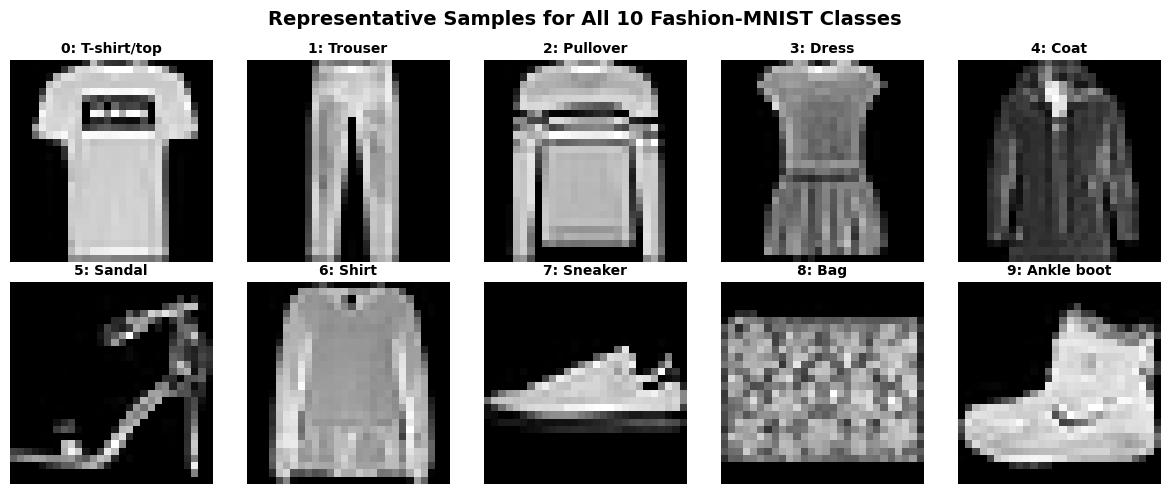

In [5]:
# ---------------------------------------------------------
# 2.5: Representative Samples (All 10 Classes)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Find the first index of each class
class_indices = {}
for idx, target in enumerate(targets):
    if target not in class_indices:
        class_indices[target] = idx
    if len(class_indices) == NUM_CLASSES:
        break

for class_id in range(NUM_CLASSES):
    idx = class_indices[class_id]
    img_tensor, label = raw_train_dataset[idx]
    ax = axes[class_id]
    ax.imshow(img_tensor.squeeze().numpy(), cmap="gray")
    ax.set_title(f"{class_id}: {CLASS_NAMES[class_id]}", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("Representative Samples for All 10 Fashion-MNIST Classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "eda_representative_samples.png"), dpi=300)
plt.show()

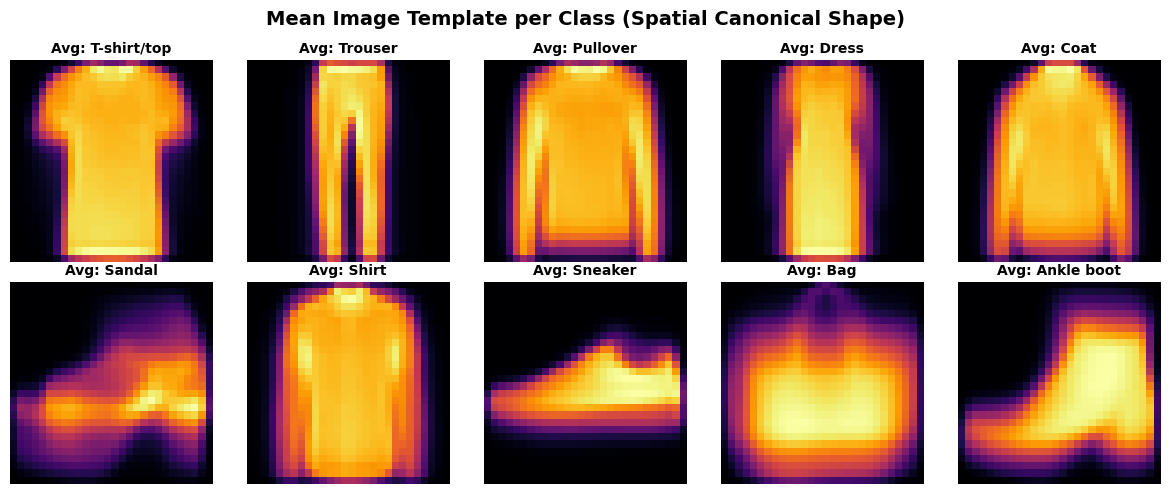

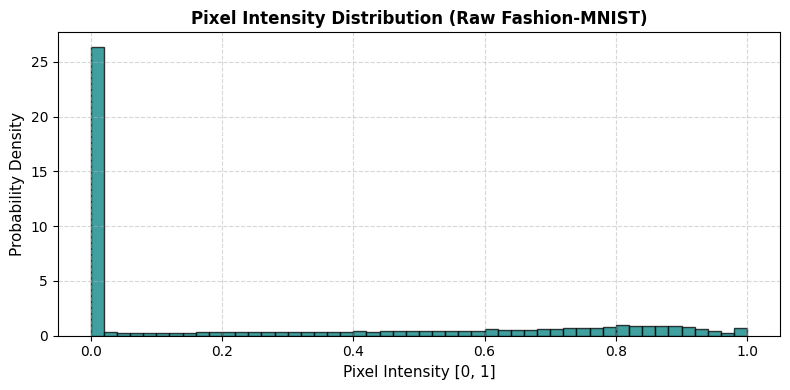

In [6]:
# ---------------------------------------------------------
# 2.6: Average Images per Class and Pixel Intensity Distribution
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for class_id in range(NUM_CLASSES):
    mask = (targets == class_id)
    class_imgs = raw_train_dataset.data[mask].float() / 255.0
    mean_class_img = class_imgs.mean(dim=0)

    ax = axes[class_id]
    ax.imshow(mean_class_img.numpy(), cmap="inferno")
    ax.set_title(f"Avg: {CLASS_NAMES[class_id]}", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("Mean Image Template per Class (Spatial Canonical Shape)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "eda_average_images.png"), dpi=300)
plt.show()

# Global Pixel Intensity Distribution
all_pixels = raw_train_dataset.data.float().numpy().flatten() / 255.0
plt.figure(figsize=(8, 4))
plt.hist(all_pixels, bins=50, color="teal", edgecolor="black", alpha=0.75, density=True)
plt.title("Pixel Intensity Distribution (Raw Fashion-MNIST)", fontsize=12, fontweight="bold")
plt.xlabel("Pixel Intensity [0, 1]", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "eda_pixel_distribution.png"), dpi=300)
plt.show()

## 3. Train / Validation / Test Split

We strictly enforce a fixed, deterministic data split protocol:
- **Official Test Set:** 10,000 samples (kept strictly for final evaluation).
- **Official Training Set (60,000 samples):** Deterministically partitioned into:
  - **Training Subset:** 54,000 samples (90%)
  - **Validation Subset:** 6,000 samples (10%)
- **Split Random Seed:** `42`
- **Data Stratification & Leakage Prevention:** We ensure zero sample index overlap between subsets.

In [7]:
# Generate deterministic split indices
total_official_train = len(raw_train_dataset)  # 60,000
val_size = 6000
train_size = total_official_train - val_size   # 54,000

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = torch.utils.data.random_split(
    range(total_official_train),
    [train_size, val_size],
    generator=generator
)

train_indices = list(train_indices.indices)
val_indices = list(val_indices.indices)

# Programmatic Verification of Split & Independence
assert len(train_indices) == 54000, f"Expected 54,000 train indices, got {len(train_indices)}"
assert len(val_indices) == 6000, f"Expected 6,000 val indices, got {len(val_indices)}"
assert len(raw_test_dataset) == 10000, f"Expected 10,000 test samples, got {len(raw_test_dataset)}"
assert len(set(train_indices).intersection(set(val_indices))) == 0, "ERROR: Train and Validation sets have overlapping indices!"

print("=" * 60)
print("SPLIT VERIFICATION SUMMARY")
print("=" * 60)
print(f"Dataset             : Fashion-MNIST")
print(f"Training Samples    : {len(train_indices):,} (54,000)")
print(f"Validation Samples  : {len(val_indices):,} (6,000)")
print(f"Test Samples        : {len(raw_test_dataset):,} (10,000)")
print(f"Split Random Seed   : {SEED}")
print(f"Index Overlap Check : PASSED (0 overlapping indices)")
print("=" * 60)

SPLIT VERIFICATION SUMMARY
Dataset             : Fashion-MNIST
Training Samples    : 54,000 (54,000)
Validation Samples  : 6,000 (6,000)
Test Samples        : 10,000 (10,000)
Split Random Seed   : 42
Index Overlap Check : PASSED (0 overlapping indices)


## 4. Preprocessing and Data Augmentation

To prevent data leakage while maintaining distinct transformation pipelines:
- **Normalization:** Z-score normalization using mean ($\mu = 0.2860$) and standard deviation ($\sigma = 0.3530$) computed strictly on the training partition.
- **Training Transformation:** `RandomHorizontalFlip(p=0.5)` + `ToTensor()` + `Normalize(mean, std)`
- **Validation & Test Transformation:** `ToTensor()` + `Normalize(mean, std)` (No stochastic augmentation).

We create a custom `FashionMNISTSubset` wrapper class so that the subsets use independent transform pipelines while operating on the exact split indices.

In [8]:
# Compute exact mean and std on the 54,000 training subset indices
train_subset_imgs = raw_train_dataset.data[train_indices].float() / 255.0
TRAIN_MEAN = train_subset_imgs.mean().item()
TRAIN_STD = train_subset_imgs.std().item()

print(f"Training Set Mean (54k split): {TRAIN_MEAN:.4f}")
print(f"Training Set Std  (54k split): {TRAIN_STD:.4f}")

# Define transformation pipelines
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(TRAIN_MEAN,), std=(TRAIN_STD,))
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(TRAIN_MEAN,), std=(TRAIN_STD,))
])

# Custom Dataset class to wrap raw data arrays with specific transforms
class FashionMNISTSubset(Dataset):
    def __init__(self, data_tensor, targets_tensor, transform=None):
        self.data = data_tensor
        self.targets = targets_tensor
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx].numpy()
        target = int(self.targets[idx])
        if self.transform:
            img = self.transform(img)
        return img, target

# Construct training, validation, and test dataset objects
train_dataset = FashionMNISTSubset(
    data_tensor=raw_train_dataset.data[train_indices],
    targets_tensor=raw_train_dataset.targets[train_indices],
    transform=train_transform
)

val_dataset = FashionMNISTSubset(
    data_tensor=raw_train_dataset.data[val_indices],
    targets_tensor=raw_train_dataset.targets[val_indices],
    transform=eval_transform
)

test_dataset = FashionMNISTSubset(
    data_tensor=raw_test_dataset.data,
    targets_tensor=raw_test_dataset.targets,
    transform=eval_transform
)

print(f"Constructed train_dataset length : {len(train_dataset):,}")
print(f"Constructed val_dataset length   : {len(val_dataset):,}")
print(f"Constructed test_dataset length  : {len(test_dataset):,}")

Training Set Mean (54k split): 0.2856
Training Set Std  (54k split): 0.3528
Constructed train_dataset length : 54,000
Constructed val_dataset length   : 6,000
Constructed test_dataset length  : 10,000


## 5. Dataset and DataLoader

We create PyTorch `DataLoader` instances with:
- **`train_loader`**: `shuffle=True`, `batch_size=64`, `pin_memory=True`
- **`val_loader`**: `shuffle=False`, `batch_size=64`, `pin_memory=True`
- **`test_loader`**: `shuffle=False`, `batch_size=64`, `pin_memory=True`

We inspect the first batch to verify shape, data type, and value ranges.

In [9]:
num_workers = 2 if os.name != 'nt' else 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda")
)

# Inspect a single batch from train_loader
sample_batch_imgs, sample_batch_labels = next(iter(train_loader))
print("--- DATALOADER BATCH SANITY CHECK ---")
print(f"Batch Images Shape : {sample_batch_imgs.shape} [B, C, H, W]")
print(f"Batch Labels Shape : {sample_batch_labels.shape} [B]")
print(f"Batch Images Dtype : {sample_batch_imgs.dtype}")
print(f"Batch Labels Dtype : {sample_batch_labels.dtype}")
print(f"Normalized Min Val : {sample_batch_imgs.min().item():.4f}")
print(f"Normalized Max Val : {sample_batch_imgs.max().item():.4f}")
print(f"Normalized Mean Val: {sample_batch_imgs.mean().item():.4f} (Close to 0)")
print(f"Normalized Std Val : {sample_batch_imgs.std().item():.4f} (Close to 1)")

assert sample_batch_imgs.shape == (BATCH_SIZE, 1, 28, 28)
assert sample_batch_labels.shape == (BATCH_SIZE,)

--- DATALOADER BATCH SANITY CHECK ---
Batch Images Shape : torch.Size([64, 1, 28, 28]) [B, C, H, W]
Batch Labels Shape : torch.Size([64]) [B]
Batch Images Dtype : torch.float32
Batch Labels Dtype : torch.int64
Normalized Min Val : -0.8096
Normalized Max Val : 2.0249
Normalized Mean Val: -0.0159 (Close to 0)
Normalized Std Val : 0.9638 (Close to 1)


## 6. Shared Training / Validation / Evaluation Utilities

To ensure a fair, unified comparative framework without code duplication:
- **Loss Function:** `nn.CrossEntropyLoss()` (all models return raw logits).
- **Optimization:** `torch.optim.Adam` with a shared base learning rate ($10^{-3}$) and weight decay ($10^{-4}$).
- **Checkpoint Selection Rule:** Model checkpoint with the **lowest validation loss** is preserved.
- **Metrics Tracked:** Loss, Accuracy, Macro-F1, Epoch Duration, Parameter Count, and Inference Latency (ms/sample).

In [10]:
def count_parameters(model: nn.Module) -> int:
    """Counts the total number of trainable parameters in a PyTorch model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:
    """Performs one complete training epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100.0
    return epoch_loss, epoch_acc

def validate_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """Evaluates model performance on the validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = (correct / total) * 100.0
    return val_loss, val_acc

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    num_epochs: int,
    device: torch.device,
    checkpoint_path: str,
    history_path: str,
    model_name: str,
    config: Dict[str, Any]
) -> Dict[str, List[float]]:
    """Unified training loop with automatic checkpointing based on lowest validation loss."""
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "epoch_time": []
    }

    best_val_loss = float("inf")
    best_epoch = -1
    best_val_acc = 0.0
    total_start_time = time.time()

    print(f"\n{'='*70}")
    print(f"STARTING TRAINING: {model_name.upper()} ({count_parameters(model):,} parameters)")
    print(f"{'='*70}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["epoch_time"].append(elapsed)

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch

            # Save best checkpoint
            torch.save({
                "model_name": model_name,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "config": config
            }, checkpoint_path)
            mark = " [* BEST CHECKPOINT SAVED]"
        else:
            mark = ""

        print(f"Epoch [{epoch:02d}/{num_epochs:02d}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}% | "
              f"Time: {elapsed:.2f}s{mark}")

    total_training_time = time.time() - total_start_time
    history["total_training_time"] = total_training_time
    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val_loss
    history["best_val_accuracy"] = best_val_acc

    # Save history as JSON
    with open(history_path, "w") as f:
        json.dump(history, f, indent=4)

    print(f"\n>>> Training Complete for {model_name} in {total_training_time:.2f}s")
    print(f">>> Best Epoch: {best_epoch} | Lowest Val Loss: {best_val_loss:.4f} | Val Acc: {best_val_acc:.2f}%")
    print(f">>> Saved Checkpoint: {checkpoint_path}")
    print(f">>> Saved History   : {history_path}")
    print(f"{'='*70}\n")
    return history

In [11]:
def load_checkpoint(model: nn.Module, checkpoint_path: str, device: torch.device) -> Dict[str, Any]:
    """Loads model weights and metadata from checkpoint."""
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found at: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return checkpoint

def load_history(history_path: str) -> Dict[str, Any]:
    """Loads training history from JSON file."""
    if not os.path.exists(history_path):
        raise FileNotFoundError(f"History file not found at: {history_path}")
    with open(history_path, "r") as f:
        return json.load(f)

def measure_inference_time(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    num_warmup: int = 5
) -> Tuple[float, float]:
    """Measures total test set inference duration and per-sample latency (in ms)."""
    model.eval()

    # Warmup
    with torch.no_grad():
        for i, (imgs, _) in enumerate(dataloader):
            if i >= num_warmup:
                break
            _ = model(imgs.to(device))

    if device.type == "cuda":
        torch.cuda.synchronize()

    total_samples = 0
    start_time = time.perf_counter()

    with torch.no_grad():
        for imgs, _ in dataloader:
            imgs = imgs.to(device)
            _ = model(imgs)
            total_samples += imgs.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize()

    total_time = time.perf_counter() - start_time
    ms_per_sample = (total_time / total_samples) * 1000.0
    return total_time, ms_per_sample

def predict(model: nn.Module, dataloader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Runs inference on dataloader and returns true labels, predicted labels, and softmax probabilities."""
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            _, preds = torch.max(logits, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

def evaluate_model(model: nn.Module, dataloader: DataLoader, device: torch.device) -> Dict[str, Any]:
    """Evaluates test accuracy, macro-F1, and per-class classification report."""
    y_true, y_pred, y_prob = predict(model, dataloader, device)
    acc = accuracy_score(y_true, y_pred) * 100.0
    macro_f1 = f1_score(y_true, y_pred, average="macro") * 100.0
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, digits=4)
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "report": report
    }

In [12]:
def plot_training_history(history: Dict[str, Any], model_name: str, save_path: Optional[str] = None):
    """Plots training and validation loss and accuracy curves with best epoch marker."""
    epochs = range(1, len(history["train_loss"]) + 1)
    best_epoch = history.get("best_epoch", np.argmin(history["val_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Curve
    ax1.plot(epochs, history["train_loss"], "b-o", label="Training Loss", markersize=4)
    ax1.plot(epochs, history["val_loss"], "r-s", label="Validation Loss", markersize=4)
    ax1.axvline(best_epoch, color="green", linestyle="--", alpha=0.8, label=f"Best Epoch ({best_epoch})")
    ax1.set_title(f"{model_name} — Loss vs. Epoch", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Epoch", fontsize=11)
    ax1.set_ylabel("Cross Entropy Loss", fontsize=11)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend(fontsize=10)

    # Accuracy Curve
    ax2.plot(epochs, history["train_accuracy"], "b-o", label="Training Accuracy", markersize=4)
    ax2.plot(epochs, history["val_accuracy"], "r-s", label="Validation Accuracy", markersize=4)
    ax2.axvline(best_epoch, color="green", linestyle="--", alpha=0.8, label=f"Best Epoch ({best_epoch})")
    ax2.set_title(f"{model_name} — Accuracy vs. Epoch", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Epoch", fontsize=11)
    ax2.set_ylabel("Accuracy (%)", fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend(fontsize=10)

    plt.suptitle(f"Training Dynamics: {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

def plot_confusion_matrix_custom(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, save_path: Optional[str] = None):
    """Generates and plots a normalized confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar_kws={'label': 'Normalized Ratio'}
    )
    plt.title(f"Confusion Matrix (Normalized): {model_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Predicted Class", fontsize=11)
    plt.ylabel("True Class", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

def find_top_confused_pairs(y_true: np.ndarray, y_pred: np.ndarray, top_k: int = 5) -> List[Tuple[str, str, int]]:
    """Identifies top off-diagonal confusion pairs."""
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)
    pairs = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if cm[i, j] > 0:
                pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_k]

def plot_prediction_grid(
    dataset: Dataset,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    model_name: str,
    num_samples: int = 5,
    save_path: Optional[str] = None
):
    """Plots a grid of correct and incorrect predictions with prediction confidence."""
    correct_indices = np.where(y_true == y_pred)[0]
    incorrect_indices = np.where(y_true != y_pred)[0]

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

    # Top Row: Correct Predictions
    for i in range(num_samples):
        idx = correct_indices[i]
        img, _ = dataset[idx]
        conf = y_prob[idx][y_pred[idx]] * 100.0
        ax = axes[0, i]
        ax.imshow(img.squeeze().numpy(), cmap="gray")
        ax.set_title(f"Pred: {CLASS_NAMES[y_pred[idx]]}\nTrue: {CLASS_NAMES[y_true[idx]]}\nConf: {conf:.1f}%",
                     color="green", fontsize=9, fontweight="bold")
        ax.axis("off")

    # Bottom Row: Incorrect Predictions
    for i in range(num_samples):
        idx = incorrect_indices[i]
        img, _ = dataset[idx]
        conf = y_prob[idx][y_pred[idx]] * 100.0
        ax = axes[1, i]
        ax.imshow(img.squeeze().numpy(), cmap="gray")
        ax.set_title(f"Pred: {CLASS_NAMES[y_pred[idx]]}\nTrue: {CLASS_NAMES[y_true[idx]]}\nConf: {conf:.1f}%",
                     color="red", fontsize=9, fontweight="bold")
        ax.axis("off")

    axes[0, 0].set_ylabel("CORRECT", fontsize=12, fontweight="bold", color="green")
    axes[1, 0].set_ylabel("INCORRECT", fontsize=12, fontweight="bold", color="red")
    plt.suptitle(f"Sample Predictions: {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

## 7. Model 1 — Linear / Softmax Classifier

### Architecture & Representation
- **Input Tensor:** $[B, 1, 28, 28]$
- **Representation:** Flattened 1D vector $[B, 784]$
- **Transform:** Direct linear projection $[B, 784] \rightarrow [B, 10]$
- **Properties:** No hidden layers, no non-linear activation functions. Outputs raw logits directly to `nn.CrossEntropyLoss()`.

In [13]:
class LinearClassifier(nn.Module):
    """
    Linear / Softmax Image Classifier.
    Maps flattened 28x28 images (784 inputs) directly to 10 class logits via a single linear layer.
    """
    def __init__(self, in_features: int = 28 * 28, num_classes: int = 10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input: [B, 1, 28, 28] -> Flatten: [B, 784] -> Linear: [B, 10]
        x = self.flatten(x)
        logits = self.linear(x)
        return logits

# Smoke Test
model_linear = LinearClassifier().to(device)
smoke_x, smoke_y = sample_batch_imgs.to(device), sample_batch_labels.to(device)
smoke_out = model_linear(smoke_x)
smoke_loss = nn.CrossEntropyLoss()(smoke_out, smoke_y)
smoke_loss.backward()
model_linear.zero_grad()

assert smoke_out.shape == (BATCH_SIZE, 10), f"Shape mismatch: {smoke_out.shape}"
print(f"[SMOKE TEST PASSED] LinearClassifier: Output shape {smoke_out.shape}, Parameters: {count_parameters(model_linear):,}")

[SMOKE TEST PASSED] LinearClassifier: Output shape torch.Size([64, 10]), Parameters: 7,850


In [14]:
# Train or Load Linear Model
linear_ckpt_path = os.path.join(CHECKPOINT_DIR, "linear_best.pth")
linear_hist_path = os.path.join(HISTORY_DIR, "linear_history.json")

if TRAIN_FLAGS["linear"]:
    linear_model = LinearClassifier().to(device)
    optimizer = torch.optim.Adam(linear_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    linear_history = train_model(
        model=linear_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        checkpoint_path=linear_ckpt_path,
        history_path=linear_hist_path,
        model_name="Linear Classifier",
        config={"lr": LEARNING_RATE, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS}
    )
else:
    if os.path.exists(linear_ckpt_path) and os.path.exists(linear_hist_path):
        linear_model = LinearClassifier().to(device)
        _ = load_checkpoint(linear_model, linear_ckpt_path, device)
        linear_history = load_history(linear_hist_path)
        print(f"[LOADED CHECKPOINT] Linear Classifier loaded from {linear_ckpt_path}")
    else:
        print(f"[STATUS] Linear Classifier not trained yet and no checkpoint found at {linear_ckpt_path}.")

[LOADED CHECKPOINT] Linear Classifier loaded from /content/drive/MyDrive/BTL-deep_learning/assignment1/checkpoints/linear_best.pth


## 8. Model 2 — Multilayer Perceptron (MLP)

### Architecture & Representation
- **Input Tensor:** $[B, 1, 28, 28]$
- **Representation:** Flattened 1D vector $[B, 784]$
- **Feedforward Layers:**
  - $\text{Linear}(784 \rightarrow 256) \rightarrow \text{ReLU}() \rightarrow \text{Dropout}(0.3)$
  - $\text{Linear}(256 \rightarrow 128) \rightarrow \text{ReLU}() \rightarrow \text{Dropout}(0.3)$
  - $\text{Linear}(128 \rightarrow 10)$
- **Properties:** Introduces non-linear representation capacity via ReLU, but ignores 2D spatial locality due to flattening.

In [15]:
class MLPClassifier(nn.Module):
    """
    Multilayer Perceptron (MLP) Classifier with two hidden layers and dropout regularization.
    """
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),             # [B, 1, 28, 28] -> [B, 784]

            nn.Linear(784, 256),      # 784 input features -> 256 neurons
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),      # 256 -> 128 neurons
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)        # 128 -> 10 class logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Smoke Test
model_mlp = MLPClassifier().to(device)
smoke_out = model_mlp(smoke_x)
smoke_loss = nn.CrossEntropyLoss()(smoke_out, smoke_y)
smoke_loss.backward()
model_mlp.zero_grad()

assert smoke_out.shape == (BATCH_SIZE, 10), f"Shape mismatch: {smoke_out.shape}"
print(f"[SMOKE TEST PASSED] MLPClassifier: Output shape {smoke_out.shape}, Parameters: {count_parameters(model_mlp):,}")

[SMOKE TEST PASSED] MLPClassifier: Output shape torch.Size([64, 10]), Parameters: 235,146


In [16]:
# Train or Load MLP Model
mlp_ckpt_path = os.path.join(CHECKPOINT_DIR, "mlp_best.pth")
mlp_hist_path = os.path.join(HISTORY_DIR, "mlp_history.json")

if TRAIN_FLAGS["mlp"]:
    mlp_model = MLPClassifier().to(device)
    optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    mlp_history = train_model(
        model=mlp_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        checkpoint_path=mlp_ckpt_path,
        history_path=mlp_hist_path,
        model_name="Multilayer Perceptron",
        config={"lr": LEARNING_RATE, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS}
    )
else:
    if os.path.exists(mlp_ckpt_path) and os.path.exists(mlp_hist_path):
        mlp_model = MLPClassifier().to(device)
        _ = load_checkpoint(mlp_model, mlp_ckpt_path, device)
        mlp_history = load_history(mlp_hist_path)
        print(f"[LOADED CHECKPOINT] MLP Classifier loaded from {mlp_ckpt_path}")
    else:
        print(f"[STATUS] MLP Classifier not trained yet and no checkpoint found at {mlp_ckpt_path}.")

[LOADED CHECKPOINT] MLP Classifier loaded from /content/drive/MyDrive/BTL-deep_learning/assignment1/checkpoints/mlp_best.pth


## 9. Model 3 — Convolutional Neural Network (CNN)

### Architecture & Spatial Inductive Bias
- **Input Tensor:** $[B, 1, 28, 28]$
- **Feature Extraction:**
  - **Conv Block 1:** $\text{Conv2d}(1 \rightarrow 32, k=3, p=1) \rightarrow \text{BatchNorm2d}(32) \rightarrow \text{ReLU}() \rightarrow \text{MaxPool2d}(2) \rightarrow [B, 32, 14, 14]$
  - **Conv Block 2:** $\text{Conv2d}(32 \rightarrow 64, k=3, p=1) \rightarrow \text{BatchNorm2d}(64) \rightarrow \text{ReLU}() \rightarrow \text{MaxPool2d}(2) \rightarrow [B, 64, 7, 7]$
- **Classification Head:**
  - $\text{Flatten}() \rightarrow [B, 3136] \rightarrow \text{Linear}(3136 \rightarrow 128) \rightarrow \text{ReLU}() \rightarrow \text{Dropout}(0.3) \rightarrow \text{Linear}(128 \rightarrow 10)$
- **Inductive Bias:** Translation equivariance, local receptive fields, and hierarchical visual feature composition.

In [17]:
class CNNClassifier(nn.Module):
    """
    Custom 2-stage Convolutional Neural Network with Batch Normalization and MaxPooling.
    """
    def __init__(self, num_classes: int = 10, dropout: float = 0.3):
        super().__init__()
        # Conv Block 1: [B, 1, 28, 28] -> [B, 32, 14, 14]
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Conv Block 2: [B, 32, 14, 14] -> [B, 64, 7, 7]
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Classifier Head: 64 * 7 * 7 = 3136 features
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        logits = self.classifier(x)
        return logits

# Smoke Test
model_cnn = CNNClassifier().to(device)
smoke_out = model_cnn(smoke_x)
smoke_loss = nn.CrossEntropyLoss()(smoke_out, smoke_y)
smoke_loss.backward()
model_cnn.zero_grad()

assert smoke_out.shape == (BATCH_SIZE, 10), f"Shape mismatch: {smoke_out.shape}"
print(f"[SMOKE TEST PASSED] CNNClassifier: Output shape {smoke_out.shape}, Parameters: {count_parameters(model_cnn):,}")

[SMOKE TEST PASSED] CNNClassifier: Output shape torch.Size([64, 10]), Parameters: 421,834


In [18]:
# Train or Load CNN Model
cnn_ckpt_path = os.path.join(CHECKPOINT_DIR, "cnn_best.pth")
cnn_hist_path = os.path.join(HISTORY_DIR, "cnn_history.json")

if TRAIN_FLAGS["cnn"]:
    cnn_model = CNNClassifier().to(device)
    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    cnn_history = train_model(
        model=cnn_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        checkpoint_path=cnn_ckpt_path,
        history_path=cnn_hist_path,
        model_name="Convolutional Neural Network",
        config={"lr": LEARNING_RATE, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS}
    )
else:
    if os.path.exists(cnn_ckpt_path) and os.path.exists(cnn_hist_path):
        cnn_model = CNNClassifier().to(device)
        _ = load_checkpoint(cnn_model, cnn_ckpt_path, device)
        cnn_history = load_history(cnn_hist_path)
        print(f"[LOADED CHECKPOINT] CNN Classifier loaded from {cnn_ckpt_path}")
    else:
        print(f"[STATUS] CNN Classifier not trained yet and no checkpoint found at {cnn_ckpt_path}.")

[LOADED CHECKPOINT] CNN Classifier loaded from /content/drive/MyDrive/BTL-deep_learning/assignment1/checkpoints/cnn_best.pth


## 10. Model 4 — LSTM Image Classifier

### Architecture & Sequential Inductive Bias
- **Sequential Image Interpretation:** The 2D image $[B, 1, 28, 28]$ is interpreted as a temporal sequence of $T = 28$ image rows, each having $D = 28$ features:
  $$[B, 1, 28, 28] \xrightarrow{\text{squeeze}} [B, 28, 28]$$
- **Recurrent Core:** $\text{nn.LSTM}(\text{input\_size}=28, \text{hidden\_size}=128, \text{num\_layers}=1, \text{batch\_first}=\text{True})$
- **Final Hidden State Extraction:** Takes the final timestep output $h_{28} \in \mathbb{R}^{B \times 128}$.
- **Classification Head:** $\text{Dropout}(0.3) \rightarrow \text{Linear}(128 \rightarrow 10)$.
- **Inductive Bias:** Recurrent directional dependency across consecutive scanlines.

In [19]:
class LSTMClassifier(nn.Module):
    """
    Sequential LSTM Image Classifier.
    Treats each 28x28 image as a sequence of 28 timesteps (rows), with 28 features (pixels per row).
    """
    def __init__(self, input_size: int = 28, hidden_size: int = 128, num_layers: int = 1, num_classes: int = 10, dropout: float = 0.3):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input shape: [B, 1, 28, 28] -> Squeeze channel: [B, 28, 28] (seq_len=28, input_size=28)
        if x.dim() == 4:
            x = x.squeeze(1)

        # LSTM forward pass: out shape [B, 28, 128], (h_n, c_n) where h_n is [num_layers, B, 128]
        out, (h_n, c_n) = self.lstm(x)

        # Take the hidden state of the final timestep (t=28)
        final_hidden = out[:, -1, :]  # [B, 128]

        # Classifier
        final_hidden = self.dropout(final_hidden)
        logits = self.fc(final_hidden)  # [B, 10]
        return logits

# Smoke Test
model_lstm = LSTMClassifier().to(device)
smoke_out = model_lstm(smoke_x)
smoke_loss = nn.CrossEntropyLoss()(smoke_out, smoke_y)
smoke_loss.backward()
model_lstm.zero_grad()

assert smoke_out.shape == (BATCH_SIZE, 10), f"Shape mismatch: {smoke_out.shape}"
print(f"[SMOKE TEST PASSED] LSTMClassifier: Output shape {smoke_out.shape}, Parameters: {count_parameters(model_lstm):,}")

[SMOKE TEST PASSED] LSTMClassifier: Output shape torch.Size([64, 10]), Parameters: 82,186


In [20]:
# Train or Load LSTM Model
lstm_ckpt_path = os.path.join(CHECKPOINT_DIR, "lstm_best.pth")
lstm_hist_path = os.path.join(HISTORY_DIR, "lstm_history.json")

if TRAIN_FLAGS["lstm"]:
    lstm_model = LSTMClassifier().to(device)
    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    lstm_history = train_model(
        model=lstm_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        checkpoint_path=lstm_ckpt_path,
        history_path=lstm_hist_path,
        model_name="LSTM Image Classifier",
        config={"lr": LEARNING_RATE, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS}
    )
else:
    if os.path.exists(lstm_ckpt_path) and os.path.exists(lstm_hist_path):
        lstm_model = LSTMClassifier().to(device)
        _ = load_checkpoint(lstm_model, lstm_ckpt_path, device)
        lstm_history = load_history(lstm_hist_path)
        print(f"[LOADED CHECKPOINT] LSTM Classifier loaded from {lstm_ckpt_path}")
    else:
        print(f"[STATUS] LSTM Classifier not trained yet and no checkpoint found at {lstm_ckpt_path}.")

[LOADED CHECKPOINT] LSTM Classifier loaded from /content/drive/MyDrive/BTL-deep_learning/assignment1/checkpoints/lstm_best.pth


## 11. Model 5 — Transformer Image Classifier

### Architecture & Global Self-Attention
- **Patch Extraction:** Non-overlapping $4 \times 4$ patches from $28 \times 28$ image:
  $$\text{Grid: } \frac{28}{4} \times \frac{28}{4} = 7 \times 7 = 49 \text{ patches (tokens)}$$
  $$\text{Raw Patch Dimension: } 1 \times 4 \times 4 = 16 \text{ values}$$
  $$[B, 1, 28, 28] \xrightarrow{\text{Unfold}} [B, 49, 16]$$
- **Linear Projection to Token Embeddings:** $\text{Linear}(16 \rightarrow 64) \rightarrow [B, 49, 64]$
- **Learnable 1D Positional Embedding:** Added elementwise: $\mathbf{E}_{pos} \in \mathbb{R}^{1 \times 49 \times 64}$
- **Transformer Encoder Stack:**
  - $L = 2$ layers
  - $d_{model} = 64$, $n_{head} = 4$ (head dimension = 16)
  - $d_{ff} = 128$, $\text{dropout} = 0.1$
- **Aggregation & Head:** Mean pooling over tokens $[B, 49, 64] \xrightarrow{\text{mean}} [B, 64] \rightarrow \text{LayerNorm}(64) \rightarrow \text{Linear}(64 \rightarrow 10)$.

In [21]:
class TransformerClassifier(nn.Module):
    """
    Vision Transformer (ViT) Classifier built from scratch with patch tokenization and Multi-Head Self-Attention.
    """
    def __init__(
        self,
        img_size: int = 28,
        patch_size: int = 4,
        in_channels: int = 1,
        num_classes: int = 10,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1
    ):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2  # 7 * 7 = 49
        self.patch_dim = in_channels * patch_size * patch_size  # 1 * 4 * 4 = 16

        # Patch extraction via Unfold
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)

        # Linear projection of flattened patches
        self.patch_projection = nn.Linear(self.patch_dim, d_model)

        # Learnable Positional Embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, d_model) * 0.02)
        self.pos_drop = nn.Dropout(dropout)

        # Transformer Encoder Layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification Head
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 1, 28, 28]
        # Unfold: [B, 16, 49] -> Transpose: [B, 49, 16]
        patches = self.unfold(x).transpose(1, 2)

        # Project to embedding dimension: [B, 49, 64]
        x = self.patch_projection(patches)

        # Add positional embedding
        x = x + self.pos_embedding
        x = self.pos_drop(x)

        # Self-Attention through Transformer Encoder: [B, 49, 64]
        x = self.transformer_encoder(x)

        # Global Average Pooling across 49 tokens: [B, 64]
        x = x.mean(dim=1)

        # LayerNorm and Classification: [B, 10]
        x = self.norm(x)
        logits = self.head(x)
        return logits

# Smoke Test
model_transformer = TransformerClassifier().to(device)
smoke_out = model_transformer(smoke_x)
smoke_loss = nn.CrossEntropyLoss()(smoke_out, smoke_y)
smoke_loss.backward()
model_transformer.zero_grad()

assert smoke_out.shape == (BATCH_SIZE, 10), f"Shape mismatch: {smoke_out.shape}"
print(f"[SMOKE TEST PASSED] TransformerClassifier: Output shape {smoke_out.shape}, Parameters: {count_parameters(model_transformer):,}")

[SMOKE TEST PASSED] TransformerClassifier: Output shape torch.Size([64, 10]), Parameters: 71,946


In [22]:
# Train or Load Transformer Model
transformer_ckpt_path = os.path.join(CHECKPOINT_DIR, "transformer_best.pth")
transformer_hist_path = os.path.join(HISTORY_DIR, "transformer_history.json")

if TRAIN_FLAGS["transformer"]:
    transformer_model = TransformerClassifier().to(device)
    optimizer = torch.optim.Adam(transformer_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    transformer_history = train_model(
        model=transformer_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        checkpoint_path=transformer_ckpt_path,
        history_path=transformer_hist_path,
        model_name="Vision Transformer",
        config={"lr": LEARNING_RATE, "batch_size": BATCH_SIZE, "epochs": NUM_EPOCHS}
    )
else:
    if os.path.exists(transformer_ckpt_path) and os.path.exists(transformer_hist_path):
        transformer_model = TransformerClassifier().to(device)
        _ = load_checkpoint(transformer_model, transformer_ckpt_path, device)
        transformer_history = load_history(transformer_hist_path)
        print(f"[LOADED CHECKPOINT] Transformer Classifier loaded from {transformer_ckpt_path}")
    else:
        print(f"[STATUS] Transformer Classifier not trained yet and no checkpoint found at {transformer_ckpt_path}.")

[LOADED CHECKPOINT] Transformer Classifier loaded from /content/drive/MyDrive/BTL-deep_learning/assignment1/checkpoints/transformer_best.pth


## 12. Final Test Evaluation

We now evaluate all five models on the official **10,000 Fashion-MNIST test dataset**.
For each model:
1. Load the best saved checkpoint (lowest validation loss).
2. Compute **Test Accuracy** and **Test Macro-F1**.
3. Measure **Inference Latency** (total time and ms per sample with CUDA synchronization).
4. Record total trainable parameters and training time.

In [23]:
# Master evaluation dictionary for all models
MODEL_SPECS = [
    {
        "name": "Linear Classifier",
        "key": "linear",
        "model_fn": lambda: LinearClassifier(),
        "ckpt": linear_ckpt_path,
        "hist": linear_hist_path
    },
    {
        "name": "Multilayer Perceptron (MLP)",
        "key": "mlp",
        "model_fn": lambda: MLPClassifier(),
        "ckpt": mlp_ckpt_path,
        "hist": mlp_hist_path
    },
    {
        "name": "Convolutional Neural Network (CNN)",
        "key": "cnn",
        "model_fn": lambda: CNNClassifier(),
        "ckpt": cnn_ckpt_path,
        "hist": cnn_hist_path
    },
    {
        "name": "LSTM Classifier",
        "key": "lstm",
        "model_fn": lambda: LSTMClassifier(),
        "ckpt": lstm_ckpt_path,
        "hist": lstm_hist_path
    },
    {
        "name": "Vision Transformer (ViT)",
        "key": "transformer",
        "model_fn": lambda: TransformerClassifier(),
        "ckpt": transformer_ckpt_path,
        "hist": transformer_hist_path
    }
]

evaluation_results = {}

for spec in MODEL_SPECS:
    m_name = spec["name"]
    m_key = spec["key"]
    ckpt_file = spec["ckpt"]
    hist_file = spec["hist"]

    if not os.path.exists(ckpt_file) or not os.path.exists(hist_file):
        print(f"[SKIP] Model '{m_name}' has no available checkpoint at {ckpt_file}. Run training first.")
        continue

    print(f"Evaluating {m_name}...")
    model_instance = spec["model_fn"]().to(device)
    ckpt = load_checkpoint(model_instance, ckpt_file, device)
    hist = load_history(hist_file)

    # Compute Test Metrics
    test_eval = evaluate_model(model_instance, test_loader, device)

    # Measure Inference Latency
    inf_total_s, inf_ms_per_sample = measure_inference_time(model_instance, test_loader, device)

    params_count = count_parameters(model_instance)
    train_time_s = hist.get("total_training_time", float("nan"))
    best_epoch = hist.get("best_epoch", ckpt.get("epoch", -1))
    best_val_loss = hist.get("best_val_loss", ckpt.get("val_loss", float("nan")))
    best_val_acc = hist.get("best_val_accuracy", ckpt.get("val_accuracy", float("nan")))

    evaluation_results[m_key] = {
        "Model": m_name,
        "Parameters": params_count,
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Best Val Acc (%)": best_val_acc,
        "Test Accuracy (%)": test_eval["accuracy"],
        "Test Macro-F1 (%)": test_eval["macro_f1"],
        "Training Time (s)": train_time_s,
        "Inference Time (s)": inf_total_s,
        "Inference (ms/sample)": inf_ms_per_sample,
        "y_true": test_eval["y_true"],
        "y_pred": test_eval["y_pred"],
        "y_prob": test_eval["y_prob"],
        "report": test_eval["report"],
        "history": hist
    }

    print(f"  -> Accuracy: {test_eval['accuracy']:.2f}% | Macro-F1: {test_eval['macro_f1']:.2f}% | Latency: {inf_ms_per_sample:.4f} ms/sample")

Evaluating Linear Classifier...
  -> Accuracy: 82.45% | Macro-F1: 82.26% | Latency: 0.3327 ms/sample
Evaluating Multilayer Perceptron (MLP)...
  -> Accuracy: 87.57% | Macro-F1: 87.51% | Latency: 0.2092 ms/sample
Evaluating Convolutional Neural Network (CNN)...
  -> Accuracy: 92.03% | Macro-F1: 92.03% | Latency: 0.2132 ms/sample
Evaluating LSTM Classifier...
  -> Accuracy: 88.15% | Macro-F1: 88.14% | Latency: 0.3114 ms/sample
Evaluating Vision Transformer (ViT)...
  -> Accuracy: 88.22% | Macro-F1: 88.05% | Latency: 0.2261 ms/sample


## 13. Model Comparison

We assemble the quantitative results into a unified summary table and export it to `results/model_comparison.csv`. We also visualize trade-offs between **Test Accuracy**, **Trainable Parameters**, and **Inference Latency**.

In [24]:
if len(evaluation_results) > 0:
    table_rows = []
    for k, res in evaluation_results.items():
        table_rows.append({
            "Model": res["Model"],
            "Parameters": res["Parameters"],
            "Best Epoch": res["Best Epoch"],
            "Val Loss": round(res["Best Val Loss"], 4),
            "Val Acc (%)": round(res["Best Val Acc (%)"], 2),
            "Test Acc (%)": round(res["Test Accuracy (%)"], 2),
            "Macro-F1 (%)": round(res["Test Macro-F1 (%)"], 2),
            "Train Time (s)": round(res["Training Time (s)"], 2),
            "Inf Time (s)": round(res["Inference Time (s)"], 4),
            "Latency (ms/sample)": round(res["Inference (ms/sample)"], 4)
        })

    df_comparison = pd.DataFrame(table_rows)
    comparison_csv_path = os.path.join(RESULTS_DIR, "model_comparison.csv")
    df_comparison.to_csv(comparison_csv_path, index=False)

    print("=" * 90)
    print("MASTER EXPERIMENTAL COMPARISON TABLE")
    print("=" * 90)
    print(df_comparison.to_string(index=False))
    print("=" * 90)
    print(f"Saved comparison table to: {comparison_csv_path}")
else:
    print("No models evaluated yet. Please train models to view comparison table.")

MASTER EXPERIMENTAL COMPARISON TABLE
                             Model  Parameters  Best Epoch  Val Loss  Val Acc (%)  Test Acc (%)  Macro-F1 (%)  Train Time (s)  Inf Time (s)  Latency (ms/sample)
                 Linear Classifier        7850          10    0.5196        82.82         82.45         82.26          324.99        3.3271               0.3327
       Multilayer Perceptron (MLP)      235146          14    0.3213        87.95         87.57         87.51          353.55        2.0924               0.2092
Convolutional Neural Network (CNN)      421834          14    0.1917        92.78         92.03         92.03          356.18        2.1325               0.2132
                   LSTM Classifier       82186          20    0.2723        90.18         88.15         88.14          325.57        3.1135               0.3114
          Vision Transformer (ViT)       71946          19    0.3183        88.58         88.22         88.05          445.34        2.2613               0.22

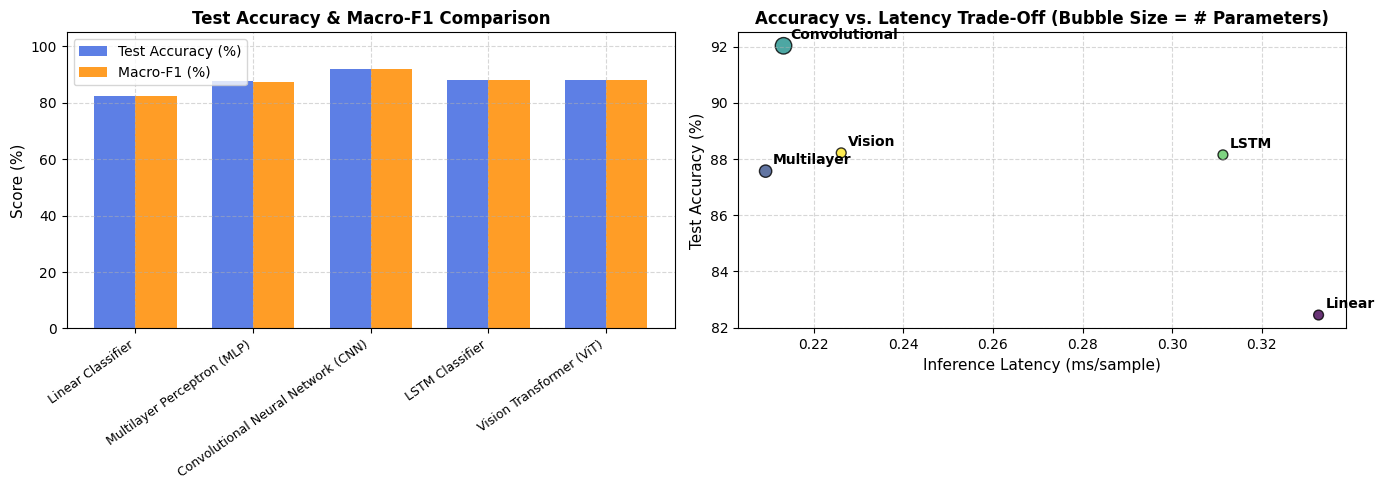

In [25]:
if len(evaluation_results) > 0:
    # Visualization: Accuracy vs Parameters and Accuracy vs Latency
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    names = [res["Model"] for res in evaluation_results.values()]
    accs = [res["Test Accuracy (%)"] for res in evaluation_results.values()]
    f1s = [res["Test Macro-F1 (%)"] for res in evaluation_results.values()]
    params = [res["Parameters"] for res in evaluation_results.values()]
    latencies = [res["Inference (ms/sample)"] for res in evaluation_results.values()]

    # Subplot 1: Test Accuracy and Macro-F1 Bar Comparison
    x = np.arange(len(names))
    width = 0.35
    ax1.bar(x - width/2, accs, width, label="Test Accuracy (%)", color="royalblue", alpha=0.85)
    ax1.bar(x + width/2, f1s, width, label="Macro-F1 (%)", color="darkorange", alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(names, rotation=35, ha="right", fontsize=9)
    ax1.set_ylabel("Score (%)", fontsize=11)
    ax1.set_title("Test Accuracy & Macro-F1 Comparison", fontsize=12, fontweight="bold")
    ax1.set_ylim(0, 105)
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()

    # Subplot 2: Parameter Count vs Latency Tradeoff
    scatter = ax2.scatter(latencies, accs, s=[max(50, p/3000) for p in params], c=range(len(names)), cmap="viridis", alpha=0.8, edgecolors="black")
    for i, txt in enumerate(names):
        ax2.annotate(txt.split()[0], (latencies[i], accs[i]), fontsize=10, fontweight="bold", xytext=(5, 5), textcoords="offset points")
    ax2.set_xlabel("Inference Latency (ms/sample)", fontsize=11)
    ax2.set_ylabel("Test Accuracy (%)", fontsize=11)
    ax2.set_title("Accuracy vs. Latency Trade-Off (Bubble Size = # Parameters)", fontsize=12, fontweight="bold")
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, "model_tradeoff_comparison.png"), dpi=300)
    plt.show()

## 14. Error Analysis

To understand model failure modes and performance discrepancies across fashion categories:
1. **Normalized Confusion Matrices** for all trained models.
2. **Per-Class Classification Metrics (Precision, Recall, F1)**.
3. **Common Off-Diagonal Confusion Pairs** (e.g., Shirt vs. T-shirt/top, Pullover vs. Coat).
4. **Qualitative Visualizations of Correct and Incorrect Predictions**.

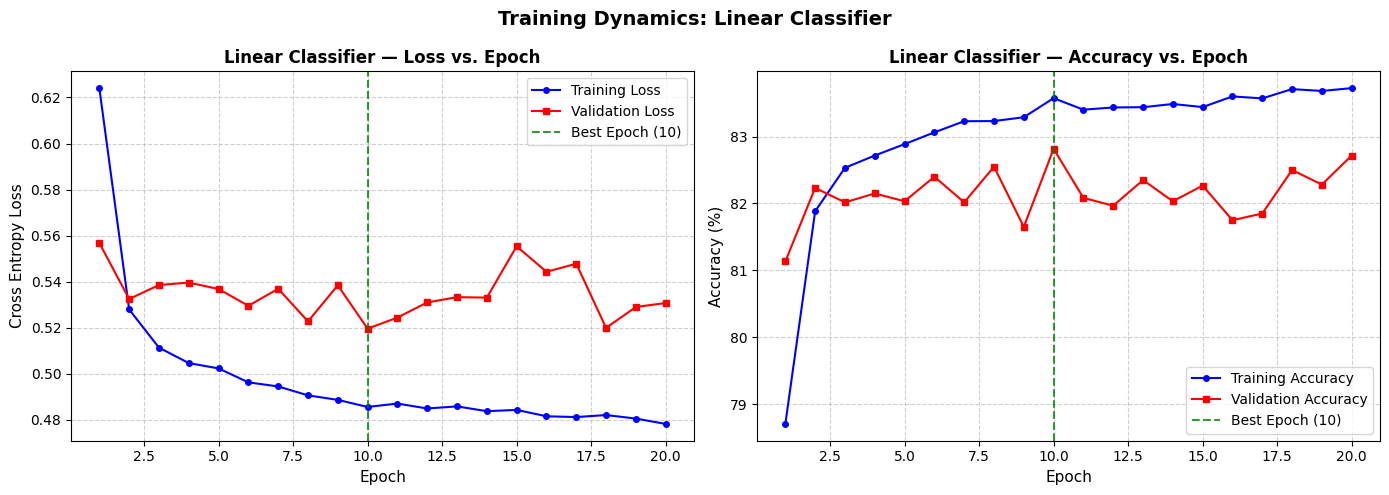

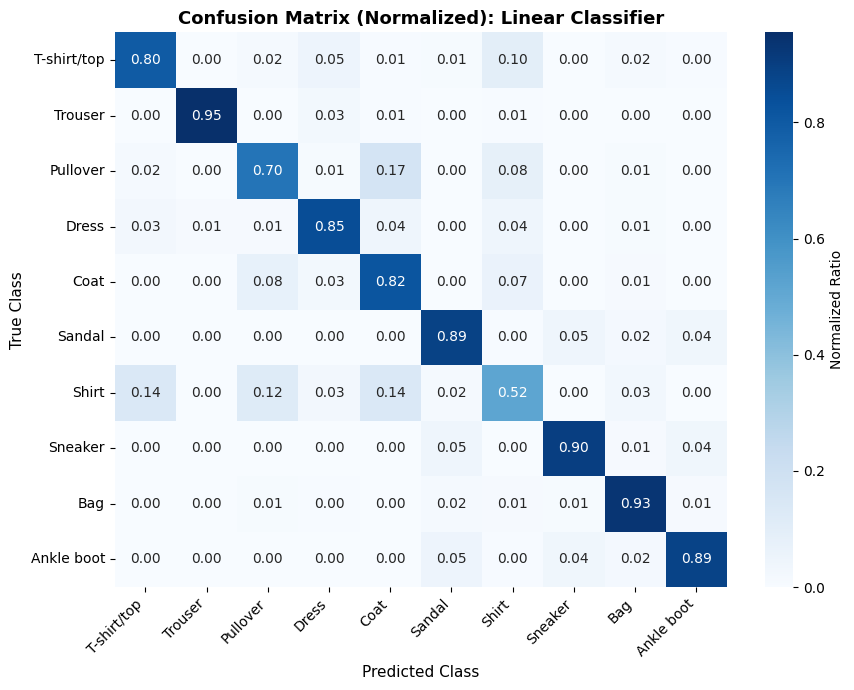


--- TOP CONFUSION PAIRS: Linear Classifier ---
  True: Pullover     -> Misclassified as: Coat         (Count: 171)
  True: Shirt        -> Misclassified as: Coat         (Count: 141)
  True: Shirt        -> Misclassified as: T-shirt/top  (Count: 139)
  True: Shirt        -> Misclassified as: Pullover     (Count: 120)
  True: T-shirt/top  -> Misclassified as: Shirt        (Count: 100)


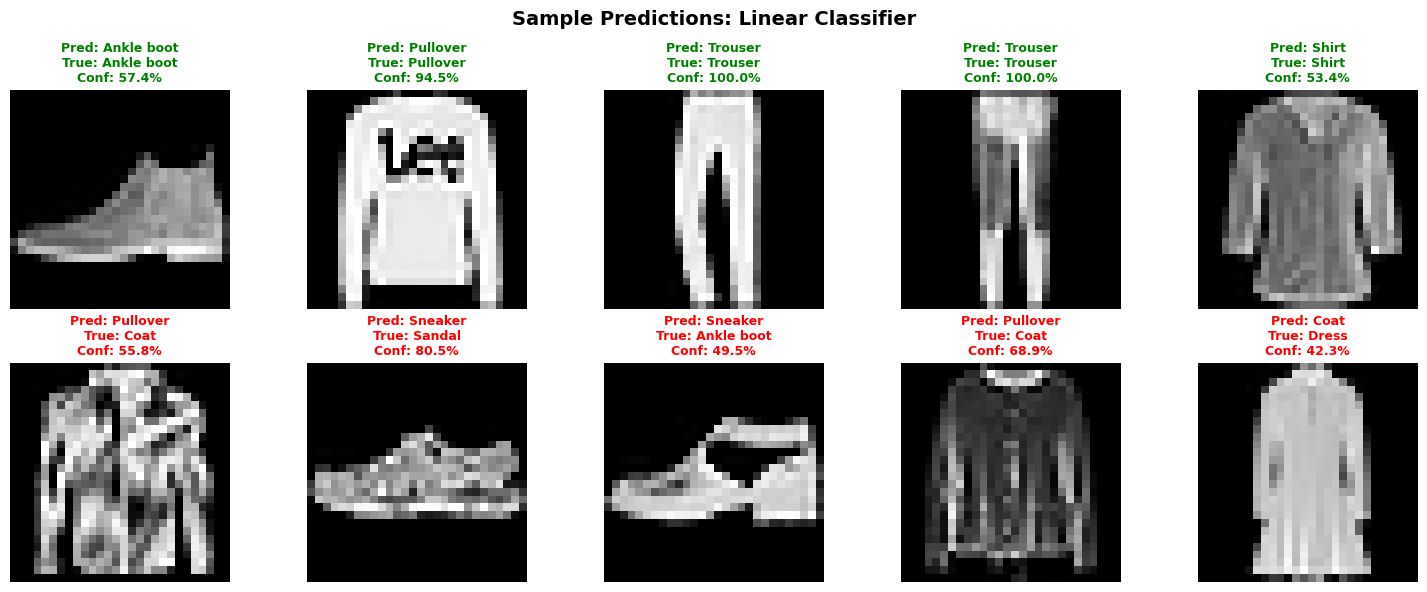

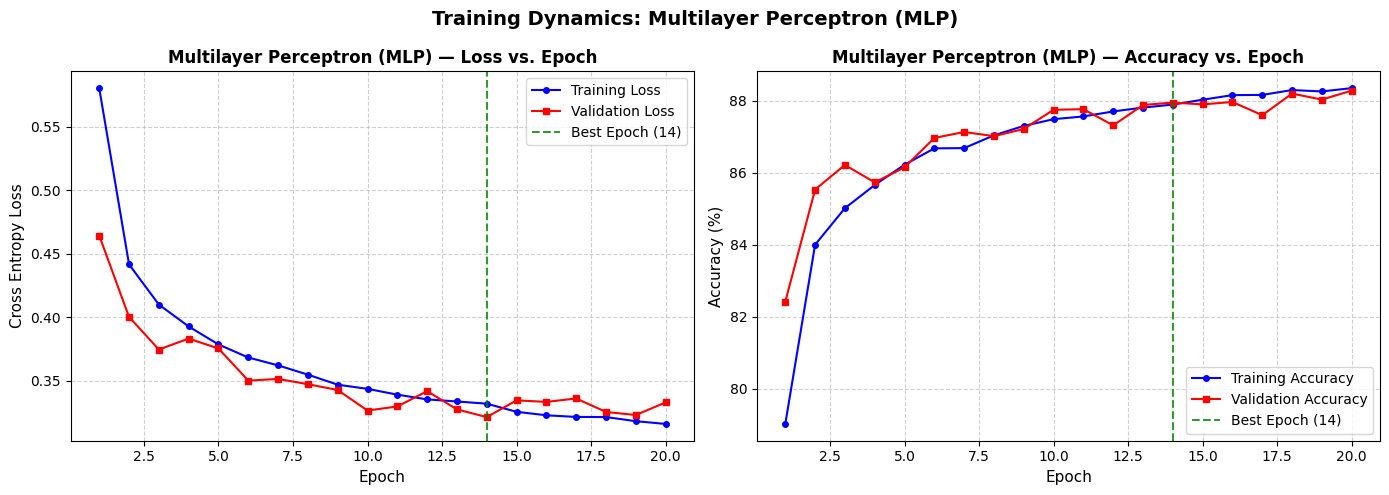

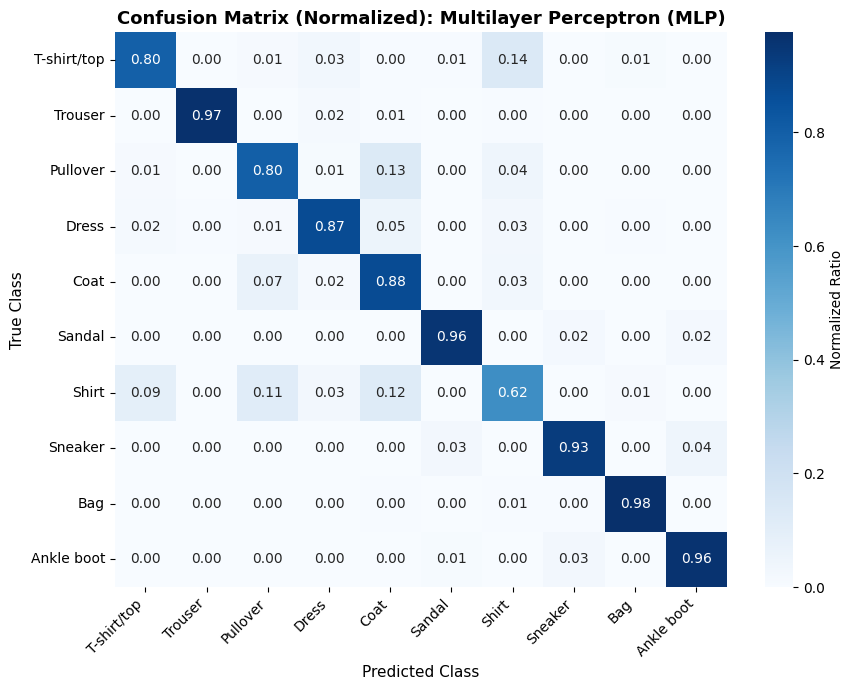


--- TOP CONFUSION PAIRS: Multilayer Perceptron (MLP) ---
  True: T-shirt/top  -> Misclassified as: Shirt        (Count: 138)
  True: Pullover     -> Misclassified as: Coat         (Count: 132)
  True: Shirt        -> Misclassified as: Coat         (Count: 125)
  True: Shirt        -> Misclassified as: Pullover     (Count: 112)
  True: Shirt        -> Misclassified as: T-shirt/top  (Count: 94)


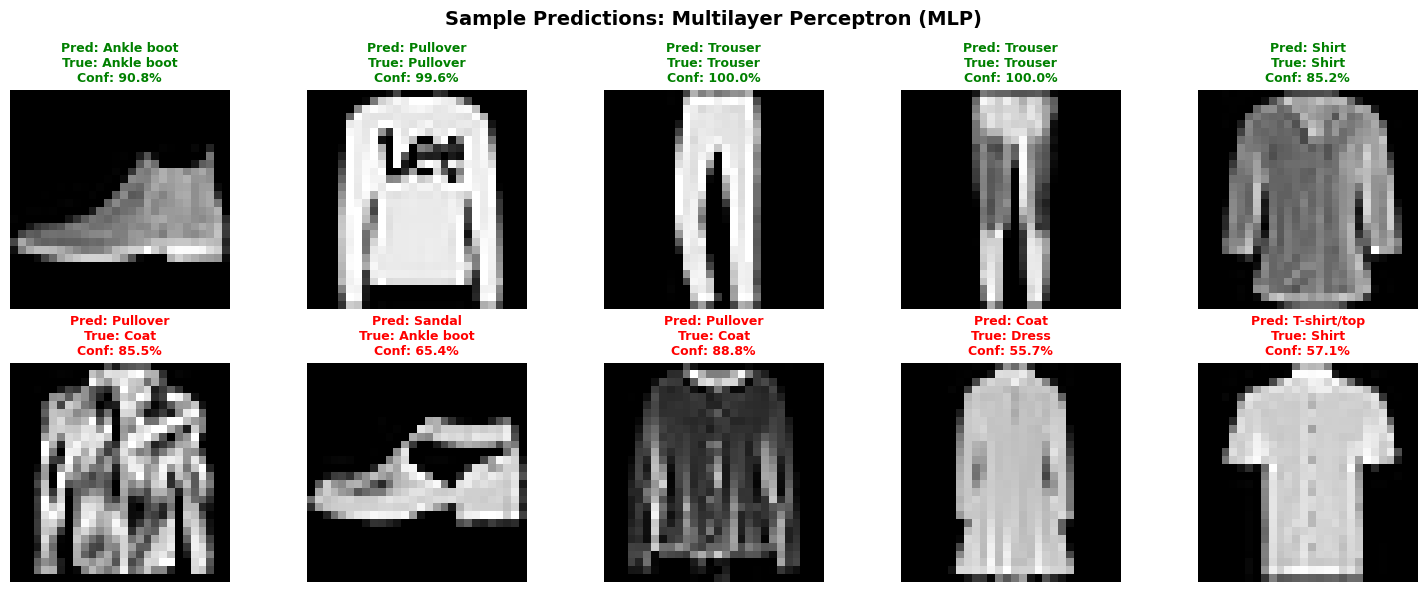

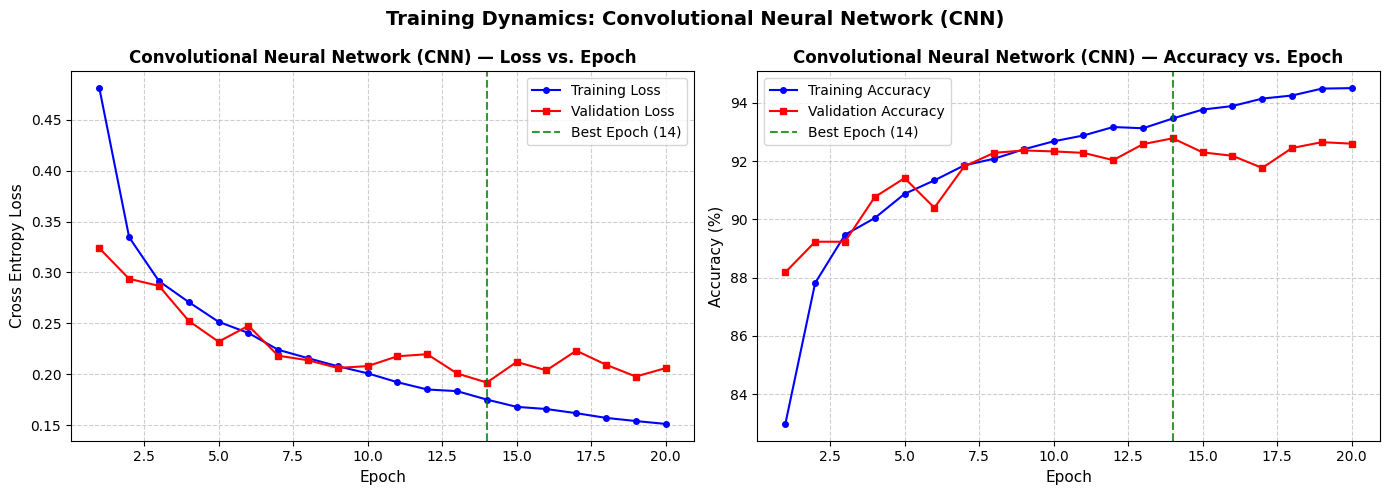

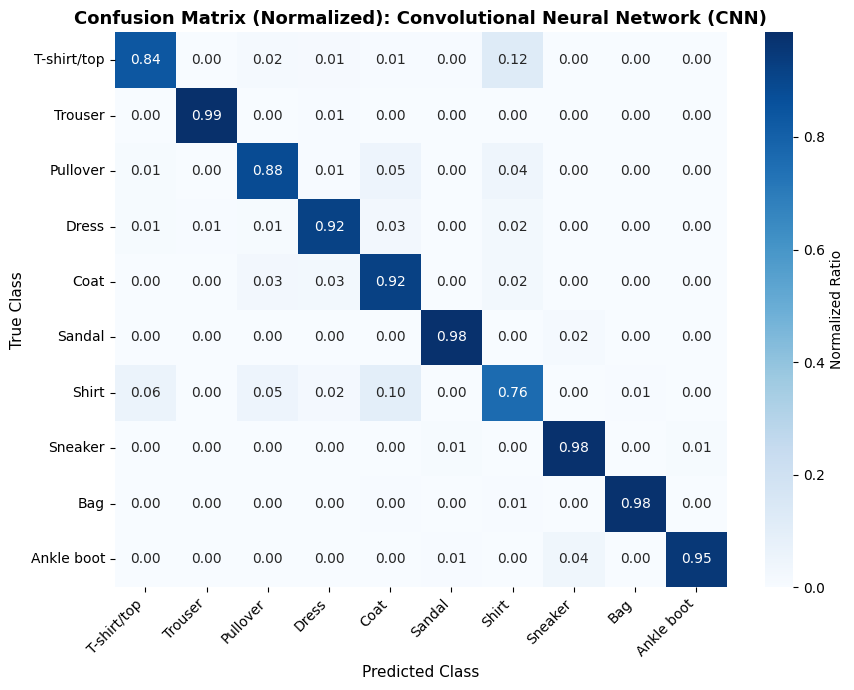


--- TOP CONFUSION PAIRS: Convolutional Neural Network (CNN) ---
  True: T-shirt/top  -> Misclassified as: Shirt        (Count: 125)
  True: Shirt        -> Misclassified as: Coat         (Count: 98)
  True: Shirt        -> Misclassified as: T-shirt/top  (Count: 59)
  True: Pullover     -> Misclassified as: Coat         (Count: 53)
  True: Shirt        -> Misclassified as: Pullover     (Count: 52)


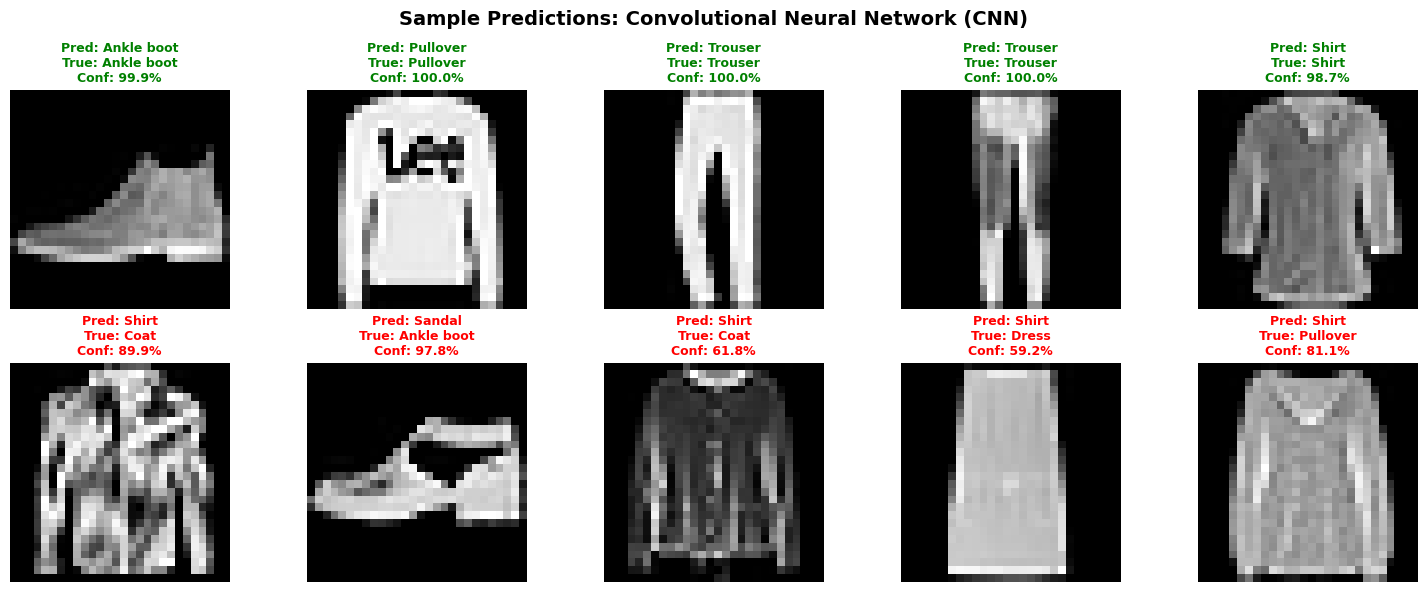

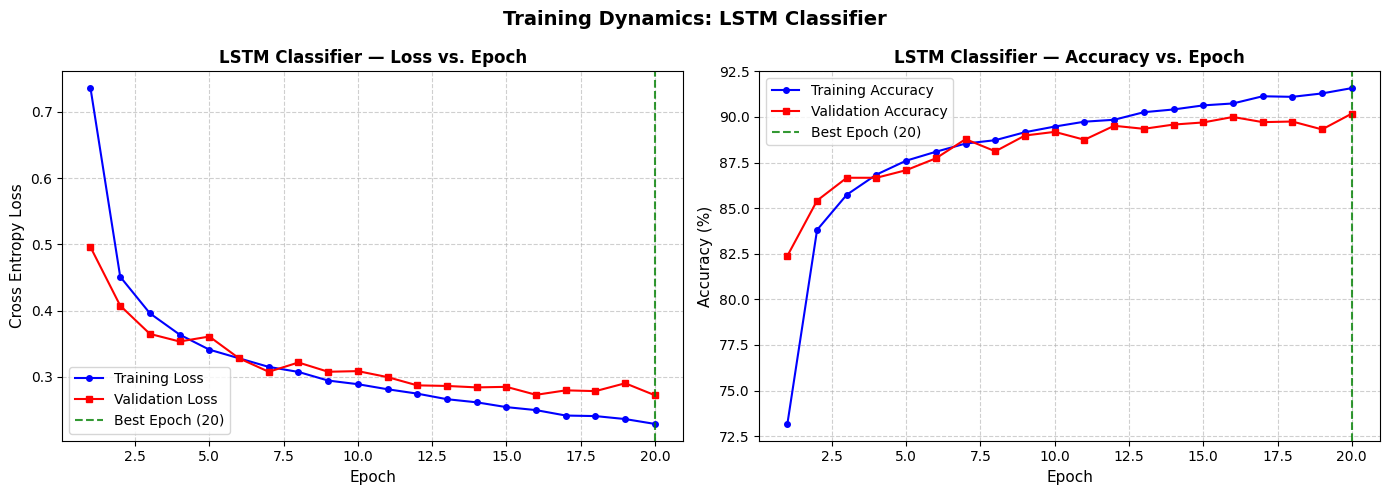

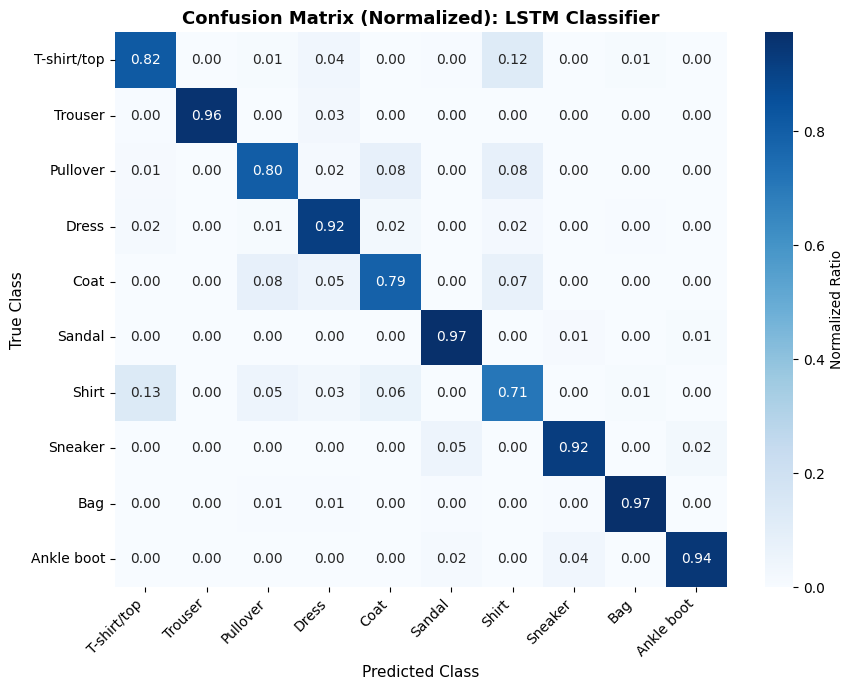


--- TOP CONFUSION PAIRS: LSTM Classifier ---
  True: Shirt        -> Misclassified as: T-shirt/top  (Count: 133)
  True: T-shirt/top  -> Misclassified as: Shirt        (Count: 122)
  True: Pullover     -> Misclassified as: Shirt        (Count: 82)
  True: Coat         -> Misclassified as: Pullover     (Count: 82)
  True: Pullover     -> Misclassified as: Coat         (Count: 81)


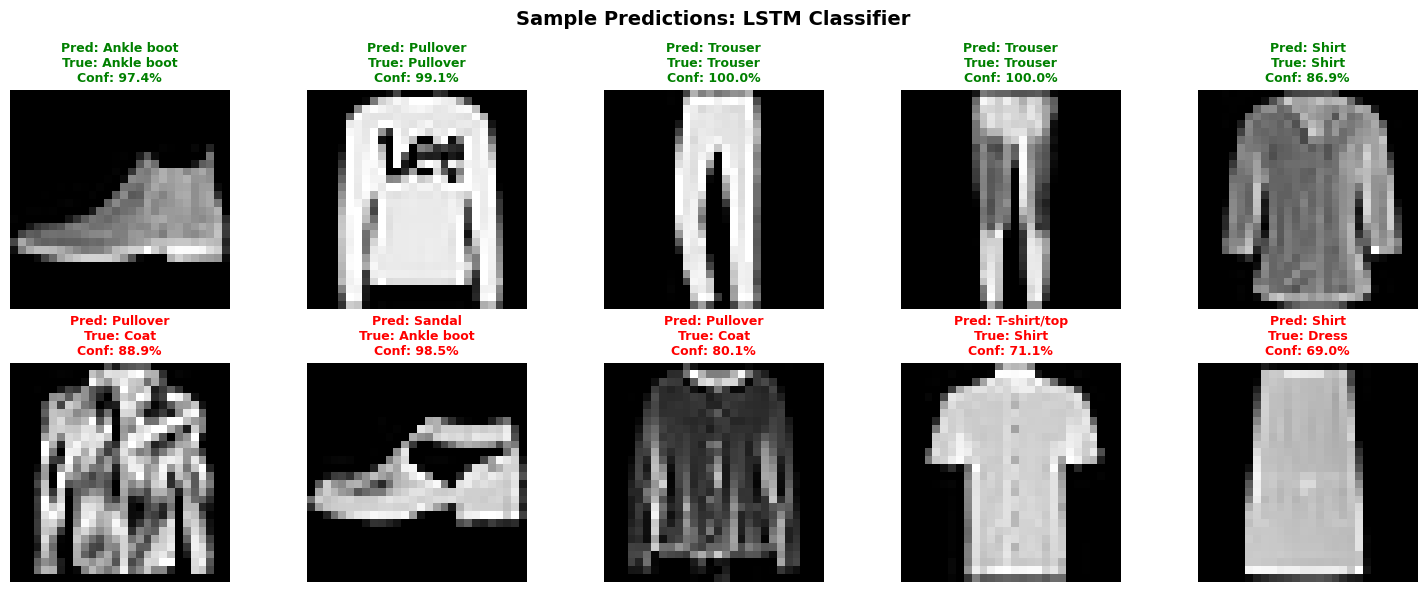

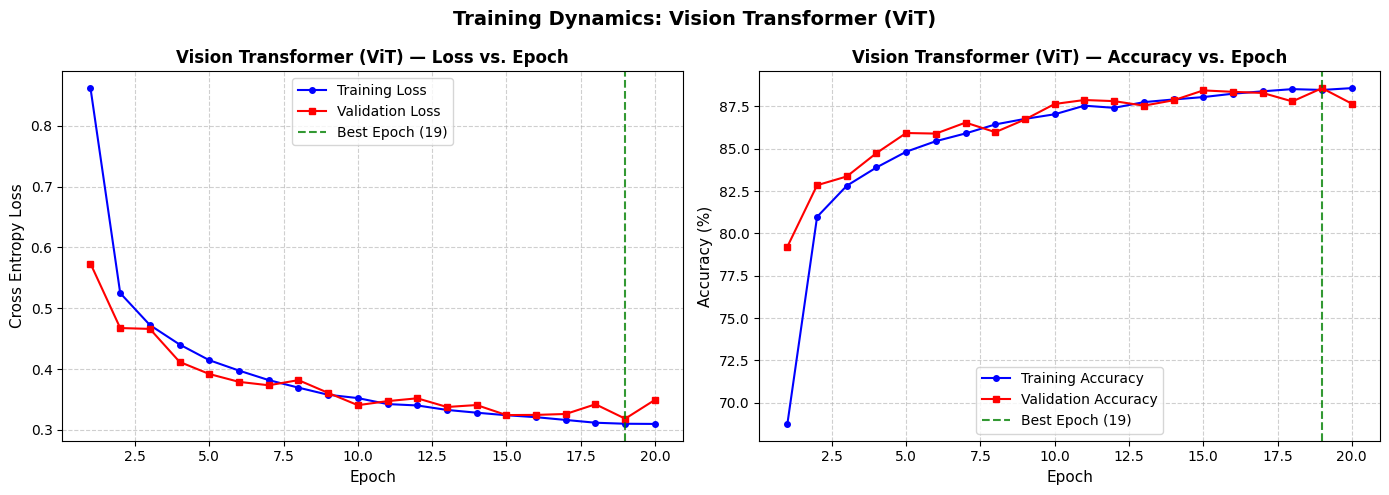

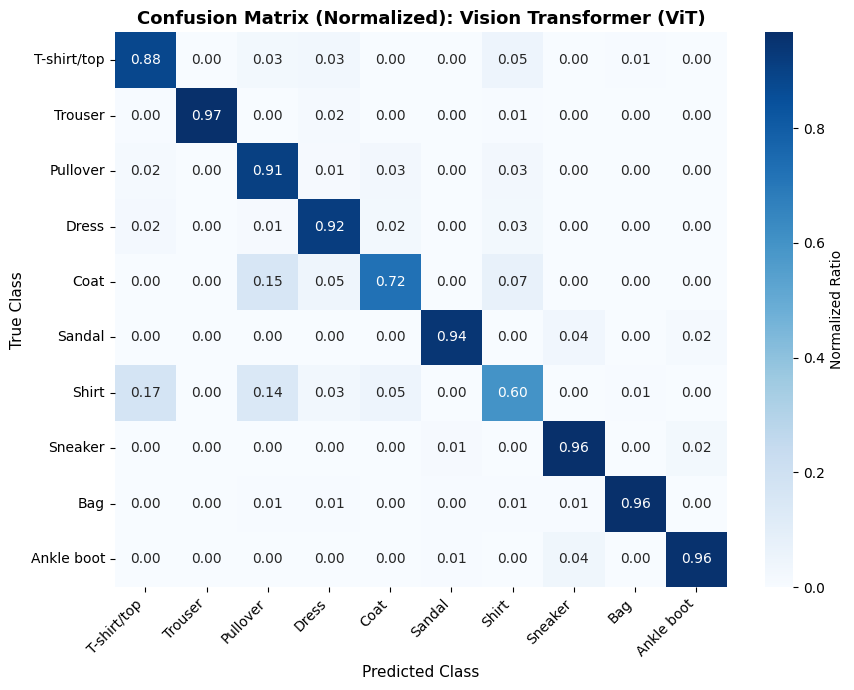


--- TOP CONFUSION PAIRS: Vision Transformer (ViT) ---
  True: Shirt        -> Misclassified as: T-shirt/top  (Count: 173)
  True: Coat         -> Misclassified as: Pullover     (Count: 155)
  True: Shirt        -> Misclassified as: Pullover     (Count: 140)
  True: Coat         -> Misclassified as: Shirt        (Count: 72)
  True: Shirt        -> Misclassified as: Coat         (Count: 51)


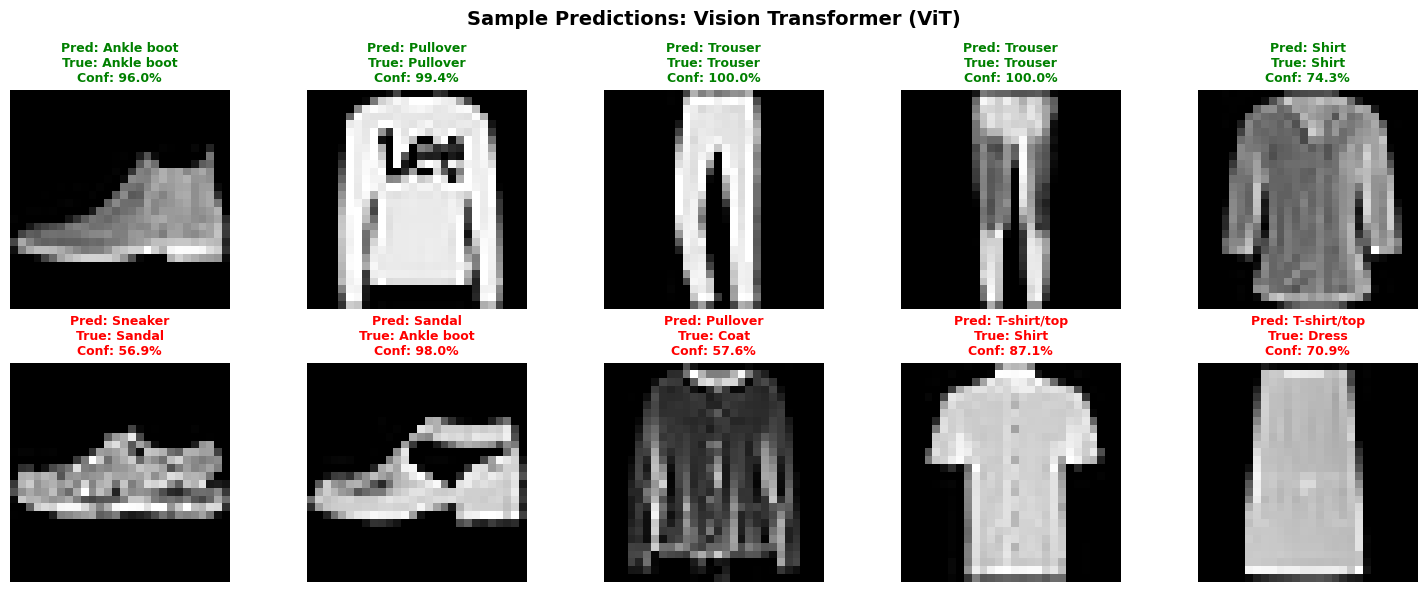

In [26]:
# Plot Training Histories and Confusion Matrices for each evaluated model
for k, res in evaluation_results.items():
    m_name = res["Model"]
    hist = res["history"]
    y_true = res["y_true"]
    y_pred = res["y_pred"]
    y_prob = res["y_prob"]

    # 1. Training Dynamics Curves
    hist_fig_path = os.path.join(FIGURE_DIR, f"{k}_training_history.png")
    plot_training_history(hist, m_name, save_path=hist_fig_path)

    # 2. Confusion Matrix
    cm_fig_path = os.path.join(FIGURE_DIR, f"{k}_confusion_matrix.png")
    plot_confusion_matrix_custom(y_true, y_pred, m_name, save_path=cm_fig_path)

    # 3. Top Confused Pairs
    top_pairs = find_top_confused_pairs(y_true, y_pred, top_k=5)
    print(f"\n--- TOP CONFUSION PAIRS: {m_name} ---")
    for true_cls, pred_cls, count in top_pairs:
        print(f"  True: {true_cls:<12} -> Misclassified as: {pred_cls:<12} (Count: {count})")

    # 4. Correct vs Incorrect Sample Predictions Grid
    pred_fig_path = os.path.join(FIGURE_DIR, f"{k}_sample_predictions.png")
    plot_prediction_grid(test_dataset, y_true, y_pred, y_prob, m_name, num_samples=5, save_path=pred_fig_path)

## 15. Experiment Summary

### Comparative Inductive Bias & Architectural Analysis

| Architecture | Input Representation | Spatial / Sequential Inductive Bias | Key Strength | Primary Limitation |
| :--- | :--- | :--- | :--- | :--- |
| **Linear Classifier** | Flattened 1D $[B, 784]$ | None (Linear projection) | Extremely fast ($<10$k params), zero hyperparameter tuning | Cannot capture spatial correlation or non-linear decision boundaries |
| **Multilayer Perceptron (MLP)** | Flattened 1D $[B, 784]$ | None (Fully connected) | Non-linear feature representation via ReLU | Ignores 2D image topology; prone to overfitting on raw pixels |
| **CNN** | Spatial 2D $[B, 1, 28, 28]$ | High (Translation equivariance & local receptive fields) | Strong spatial feature hierarchy, parameter-efficient | Rigid grid assumptions; localized receptive field depth |
| **LSTM** | Sequential Rows $[B, 28, 28]$ | Sequential temporal dependency ($T=28$) | Models directional dependencies across scanlines | Sequential bottleneck during inference; non-isotropic spatial modeling |
| **Vision Transformer (ViT)** | Patch Sequence $[B, 49, 16]$ | Low (Learned global self-attention across tokens) | Global receptive field at every layer, flexible interaction | Lacks hardwired spatial priors; requires higher sample capacity |

---
### Conclusions & Recommendations
1. **Inductive Bias vs. Data Scale:** CNNs excel on small-scale vision tasks (Fashion-MNIST) due to their built-in 2D translation equivariance and local feature extraction.
2. **Sequential vs. Spatial Modeling:** Treating an image as an LSTM row-by-row sequence imposes an unnatural directional bias, but achieves competitive non-linear modeling compared to flat MLPs.
3. **Vision Transformers from Scratch:** Transformers operate purely via self-attention over patch tokens ($4 \times 4$), demonstrating that self-attention can learn visual representations from scratch without pretrained weights or convolutional priors.